In [22]:
import numpy as np
import scipy as sp
import py3Dmol, h5py
import matplotlib.pyplot as plt

# Molecular orbitals
### visualise .cube files

In [23]:
def downsample_cube(cube_file, downsample=2):
    """Read and downsample a cube file."""
    
    with open(cube_file) as f:
        lines = f.readlines()

    # --- Header ---
    header = lines[:6]
    natoms = int(header[2].split()[0])
    atom_lines = lines[6:6+natoms]
    grid_lines = lines[6+natoms:]

    # Grid size
    nx, ny, nz = [int(header[i].split()[0]) for i in range(3,6)]

    # --- Read volumetric data ---
    data = []
    for line in grid_lines:
        data.extend([float(x) for x in line.split()])
    data = np.array(data).reshape((nx, ny, nz))

    # --- Downsample ---
    data_ds = data[::downsample, ::downsample, ::downsample]
    nx2, ny2, nz2 = data_ds.shape

    # --- Adjust voxel vectors ---
    vecs = [np.array(list(map(float, header[i].split()[1:4]))) for i in range(3,6)]
    vecs = [v * downsample for v in vecs]

    # --- Rebuild cube file as string ---
    new_lines = header[:3]

    new_lines.append(f"{nx2:5d} {vecs[0][0]:12.6f} {vecs[0][1]:12.6f} {vecs[0][2]:12.6f}\n")
    new_lines.append(f"{ny2:5d} {vecs[1][0]:12.6f} {vecs[1][1]:12.6f} {vecs[1][2]:12.6f}\n")
    new_lines.append(f"{nz2:5d} {vecs[2][0]:12.6f} {vecs[2][1]:12.6f} {vecs[2][2]:12.6f}\n")

    new_lines += atom_lines

    flat = data_ds.flatten()
    for i in range(0, len(flat), 6):
        chunk = flat[i:i+6]
        new_lines.append(" ".join(f"{v:13.5e}" for v in chunk) + "\n")

    return "".join(new_lines)


def visualize_cube_notebook(cube_file, xyz_file=None, iso=0.02, downsample=2):
    
    # Downsample cube
    cube_small = downsample_cube(cube_file, downsample)

    # Create viewer
    view = py3Dmol.view(width=800, height=600)

    # Add molecule (optional)
    if xyz_file:
        with open(xyz_file) as f:
            xyz_data = f.read()
        view.addModel(xyz_data, 'xyz')
        view.setStyle({'stick': {}})

    # Add orbital
    view.addVolumetricData(cube_small, "cube", {
        "isoval": iso,
        "color": "blue",
        "opacity": 0.9
    })
    view.addVolumetricData(cube_small, "cube", {
        "isoval": -iso,
        "color": "red",
        "opacity": 0.9
    })

    view.rotate(-45, 'x')
    view.zoomTo()
    view.zoom(1.4)
    #view.rotate(90, 'y')
    #view.rotate(-45, 'z')

    return view.show()

In [ ]:
# HOMO-1, HOMO, LUMO, LUMO+1

dir = 'dimer_opt'
for orb_name in ['orb_HOMO-1.cube', 'orb_HOMO.cube', 'orb_LUMO.cube', 'orb_LUMO+1.cube']:
    cube_file = dir + '/' + orb_name
    xyz_file  = dir + '/' + dir + '.xyz'
    visualize_cube_notebook(cube_file, xyz_file, iso=0.015, downsample=2)

In [ ]:
# Boys

dir = 'dimer_opt'
#for orb_name in ['orb_Boys0.cube', 'orb_Boys1.cube', 'orb_Boys2.cube', 'orb_Boys3.cube']:
for orb_name in ['orb_Boys1.cube', 'orb_Boys3.cube']:
    cube_file = dir + '/' + orb_name
    xyz_file  = dir + '/' + dir + '.xyz'
    visualize_cube_notebook(cube_file, xyz_file, iso=0.015, downsample=1)

In [ ]:
# partially diagonalised Boys

dir = 'dimer_opt'
for orb_name in ['orb_loc0.cube', 'orb_loc1.cube', 'orb_loc2.cube', 'orb_loc3.cube']:
    cube_file = dir + '/' + orb_name
    xyz_file  = dir + '/' + dir + '.xyz'
    visualize_cube_notebook(cube_file, xyz_file, iso=0.015, downsample=2)

In [ ]:
# Tetracene HOMO-LUMO

dir = 'tetracene'
for orb_name in ['orb_HOMO.cube', 'orb_LUMO.cube']:
    cube_file = dir + '/' + orb_name
    xyz_file  = dir + '/' + dir + '.xyz'
    visualize_cube_notebook(cube_file, xyz_file, iso=0.03, downsample=2)

# Electron-phonon coupling
### spectral density and dimensionality reduction (clustering, SVD)

[[-0.70704817  0.70716538  0.          0.        ]
 [ 0.70716538  0.70704817  0.          0.        ]
 [ 0.          0.         -0.70666478  0.70754851]
 [ 0.          0.          0.70754851  0.70666478]]
[[ 5.46513853e+00 -3.45933109e+00  3.19928816e-16  4.61604088e-03]
 [-3.45933109e+00  5.46077896e+00  8.63290646e-04 -4.83689482e-18]
 [ 2.87941757e-16  8.63290646e-04  7.43013693e+00  3.00155456e+00]
 [ 4.61604088e-03  7.22939803e-17  3.00155456e+00  7.43713217e+00]]


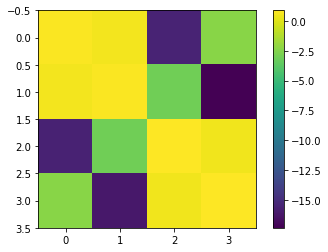

In [303]:
dir = 'dimer_opt'

# --- Read electron-phonon matrix (convert to invcm) ---
h5file = dir + '/dft-lvc-out.h5'
with h5py.File(h5file, 'r') as f:
    g_mo   = np.array(list(f['g_frontier']))      * 219474.63
    g_Boys = np.array(list(f['g_frontier_Boys'])) * 219474.63
    g_loc  = np.array(list(f['g_frontier_loc']))  * 219474.63
    omega  = np.array(list(f['omega']))           * 219474.63


'''
!!! this is just a quick hack !!!
solve this properly in dft-lvc-loc.py

Boys0 + Boys2 --> lA
Boys0 - Boys2 --> hA
Boys1 + Boys3 --> lB
Boys1 - Boys3 --> hB

at least this mapping gets the symmetry right
'''

# rows : Boys0, Boys1, Boys2, Boys3
# cols : hA,    lA,    hB,    lB
U_Boys2loc = np.array([[ 1,  1,  0,  0],
                       [ 0,  0,  1,  1],
                       [-1,  1,  0,  0],
                       [ 0,  0, -1,  1]]) / np.sqrt(2)

g = np.einsum('pi, kij, jq -> kpq', U_Boys2loc.T, g_Boys, U_Boys2loc)

'''
!!! this is another hack !!!
we diagonalise the Fock matrix in the Boys basis: 
Boys0 Boys1 Boys2 Boys3
L1    R1    L2    R2
'''

F = np.array([[ 6.44780059, -0.2293425,   0.98249919,  3.22869164],
              [-0.2293425,   6.45019057,  3.23219627,  0.98817583],
              [ 0.98249919,  3.23219627,  6.44747487, -0.228436  ],
              [ 3.22869164,  0.98817583, -0.228436,    6.44772056]])



# switch to L1 L2 R1 R2
F[[1,2],:] = F[[2,1],:]
F[:,[1,2]] = F[:,[2,1]]
#g[:,[1,2],:] = g[:,[2,1],:]
#g[:,:,[1,2]] = g[:,:,[2,1]]

# diagonalise and return sorted eigenvalues and eigenvectors
def eigsort(M):
    val, vec = np.linalg.eig(M)
    i = np.argsort(val)
    return val[i], vec[:,i]
valL, vecL = eigsort(F[:2,:2])
valR, vecR = eigsort(F[2:,2:])

# build block unitary
U = np.block([[vecL,np.zeros((2,2))],[np.zeros((2,2)), vecR]])
print(U)

# switch back to Boys0 Boys1 Boys2 Boys3
U[[1,2],:] = U[[2,1],:]
U[:,[1,2]] = U[:,[2,1]]
U_Boys2loc = U
g = np.einsum('pi, kij, jq -> kpq', U_Boys2loc.T, g_Boys, U_Boys2loc)

# this is just for diagnostics
F[[1,2],:] = F[[2,1],:]
F[:,[1,2]] = F[:,[2,1]]
print(U_Boys2loc.T @ F @ U_Boys2loc)
plt.figure()
plt.imshow(np.log10(np.abs(U_Boys2loc.T @ F @ U_Boys2loc)))
plt.colorbar()
plt.show()

''' 
end of second hack
'''

# --- Convert to exciton-phonon matrix W_{k,ij}
# g index ordering hA  lA  hB  lB  (homo/lumo, left/right)
# W index ordering SE+ SE- CT+ CT- TT
nvib = omega.shape[0]
W = np.zeros((nvib,5,5))
W[:,0,1] = 0.5 * ( g[:,2,2] - g[:,0,0] - g[:,3,3] + g[:,1,1] )
W[:,2,3] = 0.5 * ( g[:,2,2] - g[:,0,0] + g[:,3,3] - g[:,1,1] )
W[:,0,2] = g[:,1,3] - g[:,0,3]
W[:,1,3] = g[:,1,3] + g[:,0,3]
W[:,4,2] = np.sqrt(3) / 2 * ( g[:,1,2] + g[:,0,3] )
W[:,4,3] = np.sqrt(3) / 2 * ( g[:,1,2] - g[:,0,3] )
W = W + W.transpose(0,2,1)

In [ ]:
# --- el-ph coupling clustering ---
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE


def cluster_ephmat(data, n_clusters=3, random_state=0, plot=True):

    # --- k-means clustering ---
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    labels = kmeans.fit_predict(data)

    # --- dimensionality reduction to 2D ---

    tsne = TSNE(n_components=2, perplexity=30, random_state=0)
    centers = kmeans.cluster_centers_
    nc = centers.shape[0]
    data_and_centers = np.vstack((data, centers))
    data_and_centers_2d = tsne.fit_transform(data_and_centers)
    data_2d = data_and_centers_2d[:-nc]
    centers_2d = data_and_centers_2d[-nc:]

    # --- plotting ---
    if plot:
        plt.figure()
        plt.scatter(data_2d[:, 0], data_2d[:, 1], c=labels)
        plt.scatter(centers_2d[:, 0], centers_2d[:, 1], marker='*', s=200, c='r')

        plt.axis('off')
        plt.tight_layout()
        plt.title(f"K-means clustering (k={n_clusters})")

        plt.show()

    return kmeans

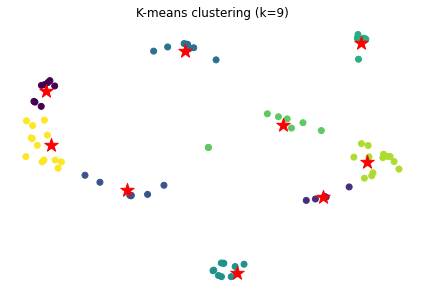

KMeans(n_clusters=9, random_state=0)

In [ ]:
def vectorize_ephmat(ephmat, normalize=True):
    """Turn e-ph coupling tensor into a matrix and normalize electronic matrices."""
    data = np.copy(ephmat).reshape(ephmat.shape[0], ephmat.shape[1]*ephmat.shape[2])
    for i in range(data.shape[0]):
        data[i] = data[i] / np.linalg.norm(data[i])
    return data

data = vectorize_ephmat(ephmat, normalize=True)
kmeans = cluster_ephmat(data, n_clusters=9, plot=True)

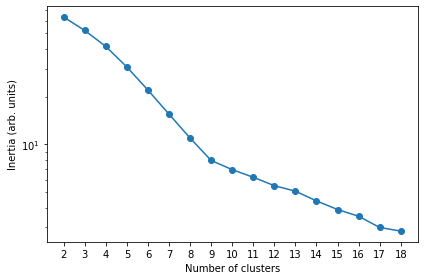

In [ ]:
# run clustering for different number of clusters and plot inertia

ks = list(range(2,19))
inertia = []
for k in ks:
    kmeans = cluster_ephmat(data, n_clusters=k, plot=False)
    inertia += [kmeans.inertia_]

plt.figure()
plt.semilogy(ks, inertia, 'o-')
plt.xticks(ks)
plt.xlabel('Number of clusters')
plt.ylabel('Inertia (arb. units)')
plt.tight_layout()
plt.show()


In [229]:
# --- Plot spectral density ---

ephmat = W

hwhm = 5
wmax = 1000
fgrid = np.linspace(1,wmax,int(wmax))

# anti-symmetrized lorentzian lineshape
def lineshape(x, freq, hwhm):
    return 2 * x * freq * hwhm  / np.arctan(freq / hwhm) \
           / ((x-freq)**2 + hwhm**2) / ((x+freq)**2 + hwhm**2)

def calculate_spectral_density(fgrid, omega, ephmat, plot=True):
    jgrid = np.zeros(fgrid.shape)
    for f,w in zip(omega,ephmat):
        jgrid += np.linalg.norm(w)**2 * lineshape(fgrid, f, hwhm)
    if plot:
        plt.figure()
        plt.plot(fgrid, jgrid, 'k-')
        plt.xlabel(r'Frequency / cm$^{-1}$')
        plt.ylabel(r'Spectral Density / cm$^{-1}$')
        plt.tight_layout()
        plt.show()
    return jgrid

## plot spectral density
#jgrid = calculate_spectral_density(fgrid, omega, ephmat, plot=True)

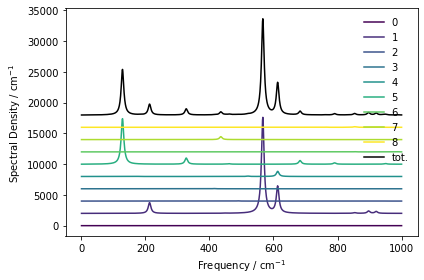

In [230]:
# --- decompose spectral density into clusters ---
nc = 9
kmeans = cluster_and_plot(data, n_clusters=nc, plot=False)
labels = kmeans.labels_


cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, nc))

yshift = 2000

plt.figure()

for n in range(nc):
    idx = labels==n
    x, y = omega[idx], ephmat[idx]
    jgrid = calculate_spectral_density(fgrid, x, y, plot=False) + yshift * n
    plt.plot(fgrid, jgrid, '-', color=colors[n], label=f'{n}')

jtot = calculate_spectral_density(fgrid, omega, ephmat, plot=False)
jtot = jtot + yshift * nc
plt.plot(fgrid, jtot, 'k-', label='tot.')
plt.xlabel(r'Frequency / cm$^{-1}$')
plt.ylabel(r'Spectral Density / cm$^{-1}$')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


In [332]:
# --- reaction coordinate of each cluster (frequency, coupling) ---

ephmat = W

labels = kmeans.labels_
centroids = kmeans.cluster_centers_
nc = centroids.shape[0]
centroids = centroids.reshape(nc, 5, 5)

cluster_freq, cluster_coup = [], []
centroid_freq, centroid_coup = [], []
centroid_sd = []

for cluster_label in range(nc):

    # normalise cluster centroid
    wc = centroids[cluster_label]
    wc_norm = np.linalg.norm(wc)
    wc = wc / wc_norm

    # rescale cluster elements
    w_cluster = ephmat[labels==cluster_label] * wc_norm

    # cluster couplings and frequencies
    w_coup = np.linalg.norm(w_cluster, axis=(1,2))
    w_freq = omega[labels==cluster_label]
    
    # reaction coordinate coupling and frequency
    rc_coup = np.sqrt(np.sum(w_coup**2))
    rc_freq = np.sum(w_freq * w_coup**2) / rc_coup**2

    # store results
    cluster_coup += [w_coup]
    cluster_freq += [w_freq]
    centroid_coup += [rc_coup]
    centroid_freq += [rc_freq]
    #centroid_sd += [rc_sd]


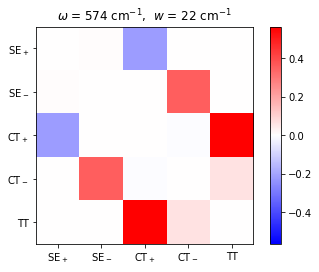

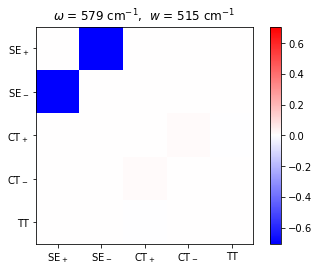

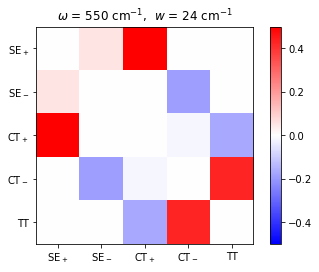

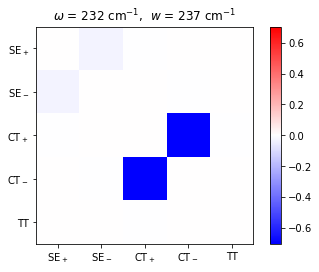

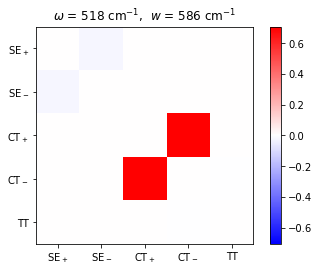

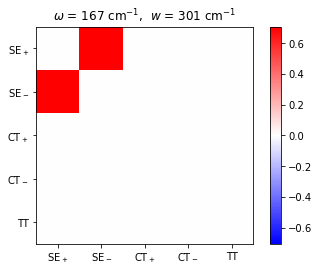

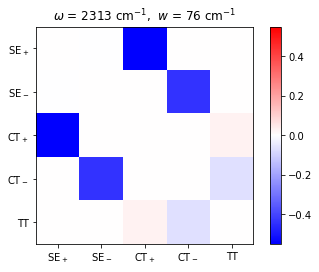

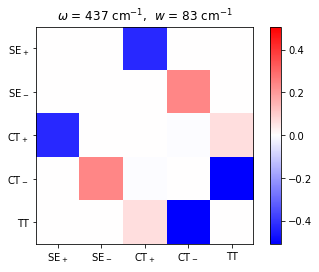

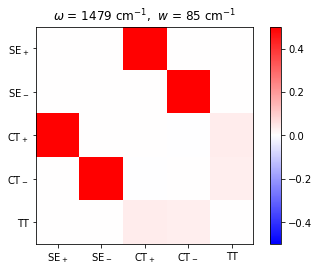

In [334]:
# --- plot system operators i.e. K-means centroids ---

from matplotlib.colors import TwoSlopeNorm

centroids = kmeans.cluster_centers_
centroids = centroids.reshape(nc, 5, 5)
for i, w in enumerate(centroids):
    w = w / np.linalg.norm(w)

    # we could calculate effective reaction coord freq and coupl (to do)

    #mat = np.abs(w)
    mat = w

    vmin = min(mat.min(), 0)
    vmax = max(mat.max(), 0)
    v = max(np.abs(vmin), np.abs(vmax))
    norm = TwoSlopeNorm(vmin=-v, vcenter=0, vmax=+v)

    plt.figure()
    plt.imshow(mat, cmap='bwr', norm=norm)
    plt.xticks(ticks=list(range(5)), labels=[r'SE$_+$', r'SE$_-$', r'CT$_+$', r'CT$_-$', r'TT'])
    plt.yticks(ticks=list(range(5)), labels=[r'SE$_+$', r'SE$_-$', r'CT$_+$', r'CT$_-$', r'TT'])
    plt.title(fr'$\omega$ = {round(centroid_freq[i])} cm$^{{-1}}$,  $w$ = {round(centroid_coup[i])} cm$^{{-1}}$')
    plt.colorbar()
    plt.show()
    


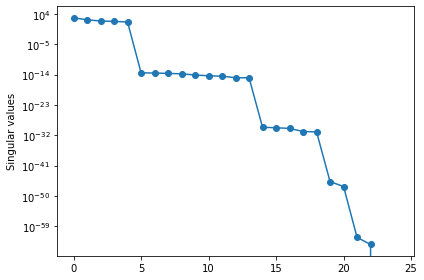

In [310]:
# --- SVD aproach of Eric Bittner et al arXiv:2407.08043 ---

data = np.copy(ephmat).reshape(ephmat.shape[0], ephmat.shape[1]*ephmat.shape[2])
#for i in range(data.shape[0]):
#    data[i] = data[i] / np.linalg.norm(data[i])

u,s,vh = np.linalg.svd(data)
plt.figure()
plt.semilogy(s,'o-')
plt.ylabel('Singular values')
plt.tight_layout()
plt.show()


First 10 frequencies of the transformed modes:
[[ 478.91560726]
 [1182.61668022]
 [ 550.91412512]
 [ 652.29508535]
 [ 806.69918678]
 [2287.79734823]
 [3006.87099708]
 [2983.21091524]
 [2215.93651953]
 [2721.13858756]]
First 10 singular values:
[[7.04665280e+02]
 [1.70472978e+02]
 [7.60339162e+01]
 [5.71935610e+01]
 [3.80795943e+01]
 [3.21319431e-14]
 [2.78101785e-14]
 [2.18476113e-14]
 [1.60447352e-14]
 [7.36872622e-15]]


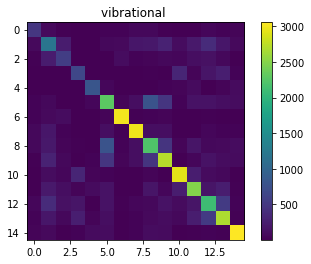

In [273]:
Hvib = u.conj().T @ np.diag(omega) @ u

print('First 10 frequencies of the transformed modes:')
print(np.diag(Hvib)[:10].reshape(10,1))
print('First 10 singular values:')
print(s[:10].reshape(10,1))

mat = np.abs(Hvib)
#mat = np.log10(mat)

plt.figure()
#nmodes = len(omega)
nmodes = 15
plt.imshow(mat[:nmodes,:nmodes])
plt.colorbar()
plt.title('vibrational ')
plt.show()

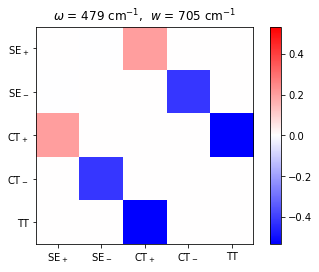

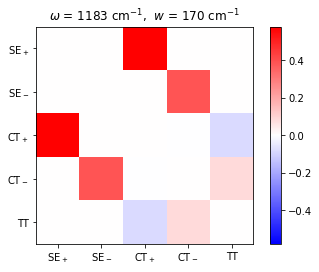

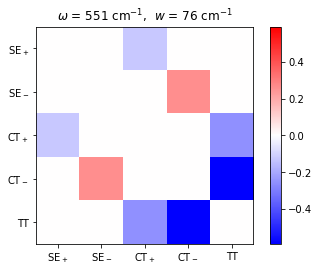

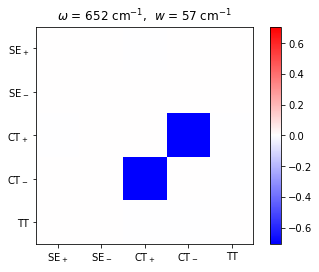

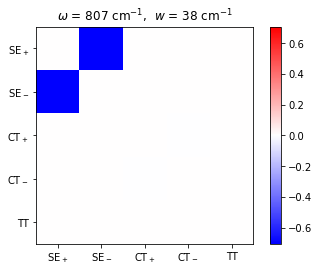

In [322]:
# transformed system operators
vh_tilde = vh.reshape(ephmat.shape[1]*ephmat.shape[2], ephmat.shape[1], ephmat.shape[2])

'''
# set small matrix elements to zero
tol = 1e-10
vh_tilde[np.abs(vh_tilde) < tol] = 0.0

print('leading system operators:')
for i in range(5):
    print('')#    print(f'coupling strength (singular value): {s[i]}')
    print('')
    print(vh_tilde[i])
'''

for i in range(5):

    #mat = np.abs(vh_tilde[i])
    mat = vh_tilde[i]

    freq = round(np.diag(Hvib)[i])
    coup = round(s[i])


    vmin = min(mat.min(), 0)
    vmax = max(mat.max(), 0)
    v = max(np.abs(vmin), np.abs(vmax))
    norm = TwoSlopeNorm(vmin=-v, vcenter=0, vmax=+v)

    plt.figure()
    plt.imshow(mat, cmap='bwr', norm=norm)
    plt.xticks(ticks=list(range(5)), labels=[r'SE$_+$', r'SE$_-$', r'CT$_+$', r'CT$_-$', r'TT'])
    plt.yticks(ticks=list(range(5)), labels=[r'SE$_+$', r'SE$_-$', r'CT$_+$', r'CT$_-$', r'TT'])
    plt.title(fr'$\omega$ = {freq} cm$^{{-1}}$,  $w$ = {coup} cm$^{{-1}}$')
    plt.colorbar()
    plt.show()

In [338]:
freqs = np.diag(Hvib)[:5]
coups = s[:5]
print(freqs)
print(coups)

print(centroid_freq)
print(centroid_coup)

[ 478.91560726 1182.61668022  550.91412512  652.29508535  806.69918678]
[704.66527994 170.47297814  76.03391617  57.19356103  38.0795943 ]
[573.778288997022, 579.1212069104101, 550.3708903032121, 232.2081545951669, 518.2910229880594, 167.43296028970087, 2313.348506360865, 436.9108051700555, 1479.3260014817465]
[22.31229429092603, 515.3363137065525, 24.061741151316962, 237.45278917045022, 586.191064002045, 300.60640546717553, 76.4295388643179, 83.14652383647818, 84.52405567447589]
